In [4]:
# Attempting to obtian the disparity mapping using dynamic programming
# Once disparity mapping is obtained, we can use it to easily obtain the depth map of the image
# This allows us to be able to esitmate the depth of objects from a camera. This is part of stereo vision cameras, in which two (asumed to be parallel) cameras on a shared baseline are used to capture the same scene from different angles.
# Allows for a numerous number of applications displayed in the lecture slides. Some test images will be included as part of the code for testing purposes
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [3]:
# Intializing procedure
# Returns Grayscale image opened
def read_image(path):
  image = cv2.imread(path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  # To prevent any potential underflow issues
  return image.astype(np.float32)

In [12]:
# Disparity Map Calculating Procedure
# Return intensity value at pixel
def intensity_at_pixel(img, pixel):
  return img[pixel[0], pixel[1]]

def calculate_current_cost(left_pixel, right_pixel, pixel_noise=2):
  return ((left_pixel - right_pixel)**2)/(pixel_noise**2)

def disparity_map(img_left, img_right):
  # Read both (left and right) images in RGB format
  left_image = read_image(img_left)
  right_image = read_image(img_right)
  # Defining intial parameters:
  pixel_noise = 2
  skip_cost = 1
  height, width = left_image.shape
  # Output image placeholder
  disparity_left = np.zeros((height, width), dtype=np.float32)
  disparity_right = np.zeros((height, width), dtype=np.float32)
  for row in range(height):
  # Initialize D matrix
  # Cost will be according to each given scanline
    D = np.zeros((width,width))
    # Cost will be computed according to a predefined formula:
    # dij = ((Il(i) - Ir(j))^2/pixel_noise^2, where dij is the cost of matching pixel Il(i) to Ir(j)
    # D(1,1) =  d11 && D(i,j) = min(D(i-1, j-1) + dij, D(i-1, j) + skip_cost, D(i, j-1) + skip cost)
    for i in range(width):
      for j in range(width):
        # Intensity value at left image
        left_image_pixel = intensity_at_pixel(left_image, (row, i))
        # Intensity value at right image
        right_image_pixel = intensity_at_pixel(right_image, (row, j))
        # Cost associated with left and right current pixel intensities
        current_cost = calculate_current_cost(left_image_pixel, right_image_pixel, pixel_noise)
        if i == 0 and j == 0:
          # If still at first point
          D[i, j] = current_cost
        else:
          if i == 0:
            # If at first point in current scan line in left image
            D[i, j] = D[i, j-1] + skip_cost
          elif j == 0:
            # If at first point in current scan line in right image
            D[i, j] = D[i-1, j] + skip_cost
          else:
            # Proceed with the algorithm normally
            D[i, j] = min((D[i-1, j-1] + current_cost), (D[i-1, j] + skip_cost), (D[i, j-1] + skip_cost))
    # Finding the optimal cost through backtracking across the entire D matrix to determine which points are skipped, which are present etc...
    # Backtracking per row
    i = width - 1
    j = width - 1

    target_scanline = 50
    if row == target_scanline:
      # Horizontal axis (Ir)
      x_coordinates = [j]
      # Vertical axis (Il)
      y_coordinates = [i]

    # Tracing the optimal path up to 0,0
    # Making disparity maps for both left and right images
    while i > 0 and j > 0:
      match_cost = D[i-1, j-1]
      skip_left = D[i-1, j]
      skip_right = D[i, j-1]

      # Check the minimum
      minimum_cost_path = min(match_cost, skip_left, skip_right)

      if minimum_cost_path == match_cost:
        disparity_left[row, i] = abs(j - i)
        disparity_right[row, j] = abs(j - i)
        i -= 1
        j -= 1
      elif minimum_cost_path == skip_left:
        disparity_left[row, i] = 0
        i -= 1
      elif minimum_cost_path == skip_right:
        disparity_right[row, j] = 0
        j -= 1

      if row == target_scanline:
        x_coordinates.append(j)
        y_coordinates.append(i)

    # Backtracking edge cases:
    while i > 0:
      disparity_left[row, i] = 0
      i -= 1
      if row == target_scanline:
        x_coordinates.append(j)
        y_coordinates.append(i)
    while j > 0:
      disparity_right[row, j] = 0
      j -= 1
      if row == target_scanline:
        x_coordinates.append(j)
        y_coordinates.append(i)

  return disparity_left, disparity_right, x_coordinates, y_coordinates


In [14]:
def plot_disparity_map(disparity):
  plt.imshow(disparity, cmap='plasma')
  plt.title('Disparity Map')
  plt.colorbar(label='Pixel Disparity')
  plt.show()

In [18]:
def plot_alignment_for_scanline(x_coordinates, y_coordinates):
  plt.plot(x_coordinates, y_coordinates, marker='o', linestyle='-')
  # Invert axis from N, N to 1,1
  plt.gca().invert_yaxis()
  plt.title('Scanline Alignment Plot for Row 50')
  plt.xlabel('Right Image Pixel Index')
  plt.ylabel('Left Image Pixel Index')
  plt.grid(True)
  plt.show()


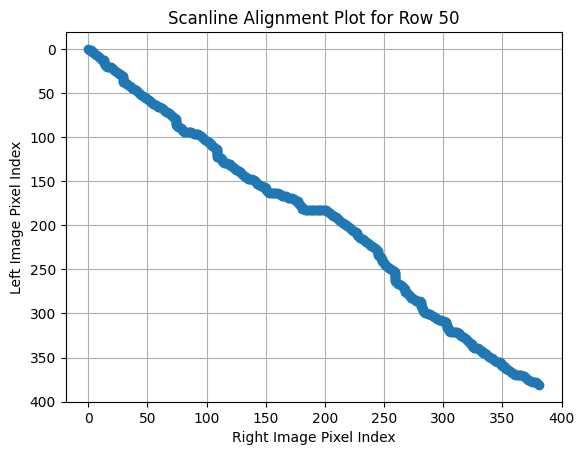

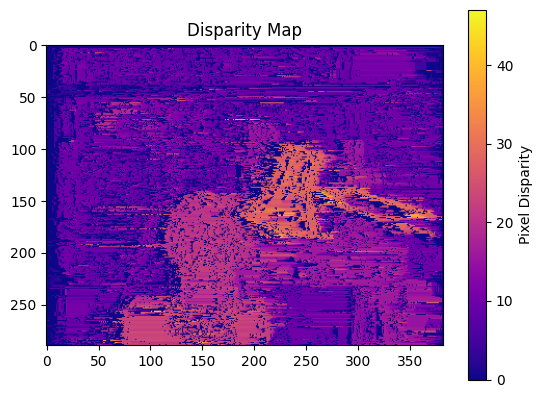

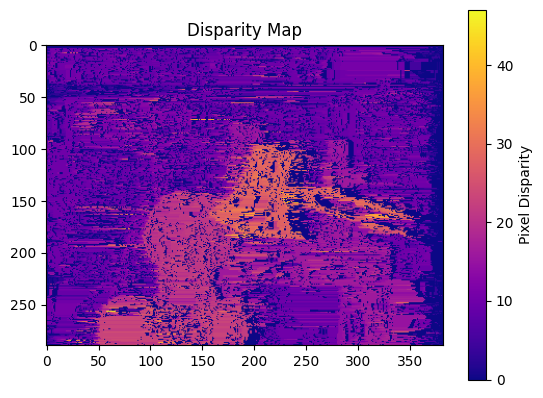

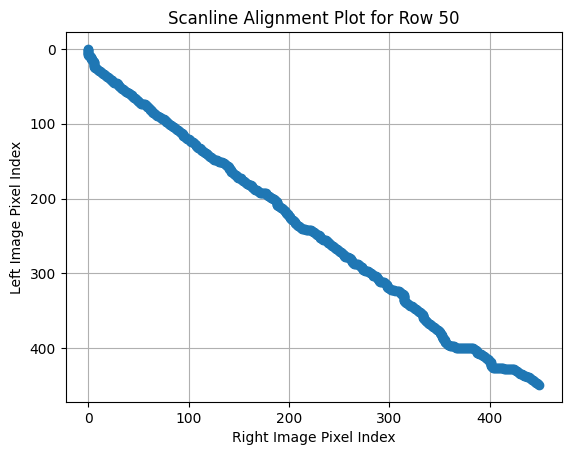

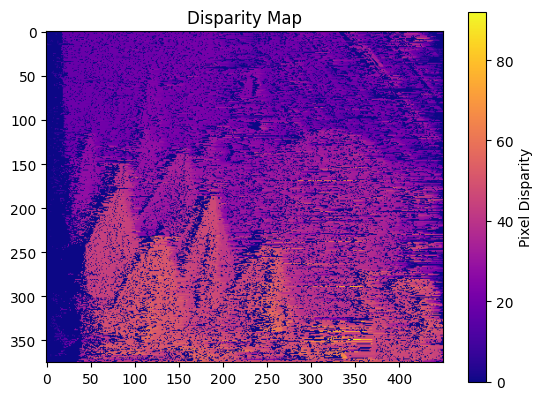

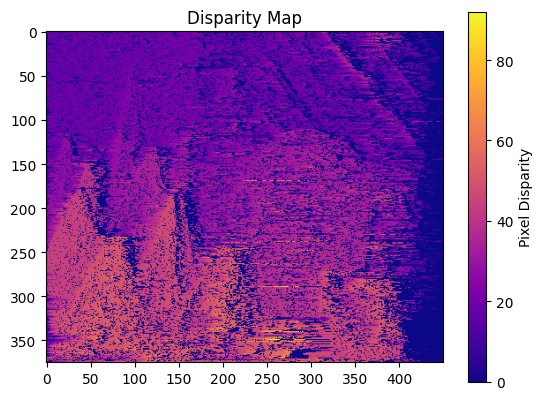

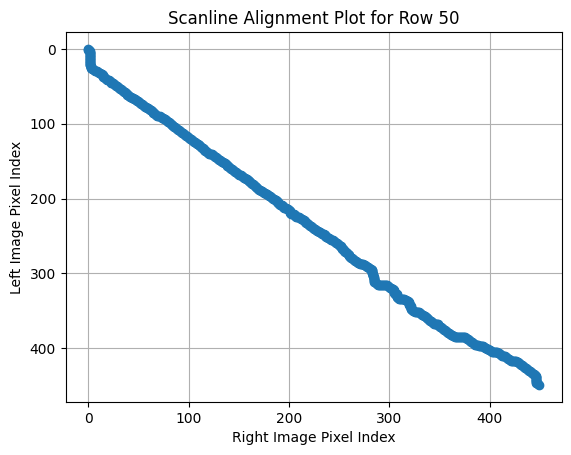

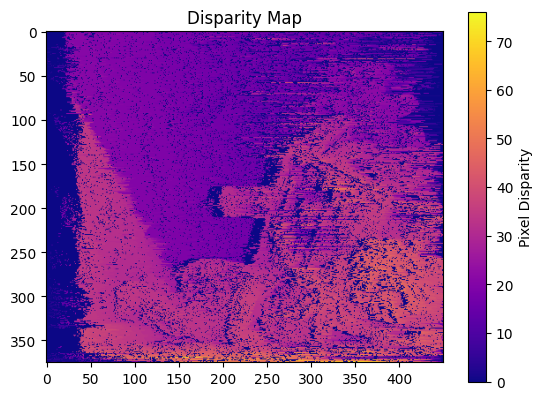

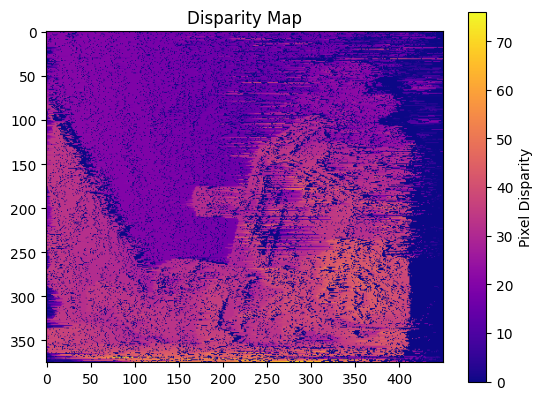

In [19]:
# Testing:
# Disparity Maps for first image
left_1, right_1, x_1, y_1 = disparity_map('l1.png', 'r1.png')
plot_alignment_for_scanline(x_1, y_1)
plot_disparity_map(left_1)
plot_disparity_map(right_1)

# Disparity Maps for second image
left_2, right_2, x_2, y_2 = disparity_map('l2.png', 'r2.png')
plot_alignment_for_scanline(x_2, y_2)
plot_disparity_map(left_2)
plot_disparity_map(right_2)

# Disparity Maps for third image
left_3, right_3, x_3, y_3 = disparity_map('l3.png', 'r3.png')
plot_alignment_for_scanline(x_3, y_3)
plot_disparity_map(left_3)
plot_disparity_map(right_3)